# EXERCISE 2B

Imagine you are a data scientist working for an international development organization. Your team wants to understand how countries differ in terms of economy, health, and social well-being. You have access to a dataset containing multiple indicators for countries worldwide, such as GDP per capita, life expectancy, child mortality, and population.

Your task is to discover natural groupings of countries using hierarchical clustering. By examining these clusters, you can identify patterns such as:

- Which countries are economically developed or developing

- How social and health indicators vary across regions

- Surprising similarities between countries from different continents

Answer each question by completing the corresponding code cell. **Do not remove or reorder cells.**



<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/7/71/IMF_advanced_economies_and_UN_least_developed_countries.svg/960px-IMF_advanced_economies_and_UN_least_developed_countries.svg.png"/>

## Dataset feature description

 - child mort - Death of children under 5 years of age per 1000 live births

- exports - Exports of goods and services per capita. Given as %age of the GDP per capita
- health - Total health spending per capita. Given as %age of GDP per capita
- import - Imports of goods and services per capita. Given as %age of the GDP per capita
- income - Net income per person
- inflation - The measurement of the annual growth rate of the Total GDP
- life_expec - The average number of years a new born child would live if the current mortality patterns are to remain the same
- total_fer - The number of children that would be born to each woman if the current age-fertility rates remain the same.
- gdpp - The GDP per capita. Calculated as the Total GDP divided by the total population.

## 1. Import Required Libraries
Import the core libraries needed for data analysis, visualization, and clustering.

In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px # Import plotly.express

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import scale

## 2. Load the Dataset
Upload the CSV file for *the* **Country Data** dataset.

In [207]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Path to dataset files: /kaggle/input/unsupervised-learning-on-country-data
True


## 3. Exploring the Dataset

Display the first 10 rows of the dataset `(5 pts)`

- Show the initial records to understand the dataset's structure and variables.

In [208]:
# put your answer here
df.head(10)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


Display the shape of the dataset `(5 pts)`
- How many rows (countries) and how many features does the dataset contain?

In [209]:
# put your answer here
df.shape

(167, 10)

Show summary statistics using `describe()`. `(5 pts)`

In [210]:
# put your answer here
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


Check for missing values. `(5 pts)`

In [211]:
# put your answer here
print(df.to_string())

                            country  child_mort  exports  health   imports  income  inflation  life_expec  total_fer    gdpp
0                       Afghanistan        90.2   10.000    7.58   44.9000    1610      9.440        56.2       5.82     553
1                           Albania        16.6   28.000    6.55   48.6000    9930      4.490        76.3       1.65    4090
2                           Algeria        27.3   38.400    4.17   31.4000   12900     16.100        76.5       2.89    4460
3                            Angola       119.0   62.300    2.85   42.9000    5900     22.400        60.1       6.16    3530
4               Antigua and Barbuda        10.3   45.500    6.03   58.9000   19100      1.440        76.8       2.13   12200
5                         Argentina        14.5   18.900    8.10   16.0000   18700     20.900        75.8       2.37   10300
6                           Armenia        18.1   20.800    4.40   45.3000    6700      7.770        73.3       1.69    3220


## 4. Data Preprocessing

Select only the numerical columns for clustering `(5 pts)`
- Exclude any non-numeric fields, such as 'Country Name' or categorical variables.

In [212]:
# put your answer here
df_excluded = df.drop(['country'], axis=1)
df_excluded

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


Standardize the selected numerical features `(5 pts)`

- This ensures all features contribute equally to the distance calculations used in clustering.

In [213]:
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_excluded), columns=list(df_excluded.columns.values))
df_scaled.head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817
5,-0.591177,-0.812628,0.468966,-1.279787,0.080920,1.244725,0.591474,-0.382933,-0.145791
6,-0.501643,-0.743107,-0.882089,-0.065883,-0.543421,-0.001123,0.309514,-0.833471,-0.533233
7,-0.832423,-0.779697,0.699011,-1.076779,1.261966,-0.628316,1.290735,-0.674457,2.130699
8,-0.844858,0.372890,1.527901,0.037693,1.355617,-0.655549,1.121559,-0.999109,1.857082
9,0.023128,0.482661,-0.341667,-1.085065,-0.059556,0.571037,-0.164178,-0.681083,-0.389857


## 5. Exploratory Data Analysis

Generate a correlation heatmap
- Visualize the relationships between socioeconomic indicators. `(10 pts)`

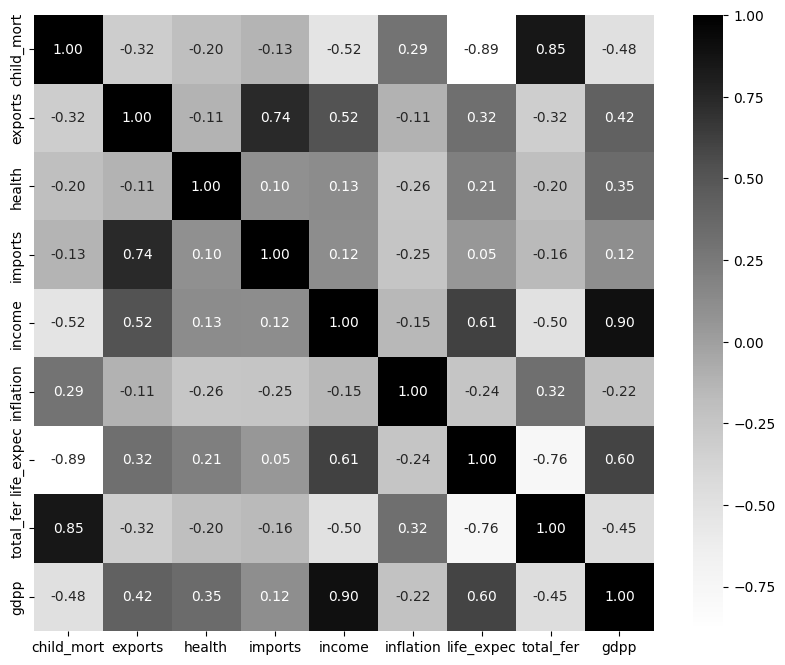

In [214]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_scaled.corr(numeric_only=True), annot=True, cmap='Greys', fmt=".2f")
plt.show()

Identify 2–3 variables that appear strongly correlated `(10 pts)`
- Explain your observations in the text cell below.

### **Put your answer here**

*In my observation, the heatmap shows that income and gdpp are highly correlated with a score of 0.90. Likewise, child_mort and total_fer also show a strong correlation of 0.85. These two pairs represent the strongest relationships in the heatmap. On the other hand, features like life_expect and gdpp show a moderate relationship, with a correlation of around 0.60.*

*This suggests that income and GDP per capita are closely related as income increases, GDP per capita tends to increase as well, which aligns with real-world economic behavior. Similarly, the moderate correlation between life expectancy and GDP per capita indicates that higher GDP per capita is often associated with longer life expectancy, since better economic conditions typically improve healthcare and quality of life.*





## 6. Hierarchical Clustering

# Compute and display a dendrogram using the linkage method `(10 pts)`
- Use `'ward'` linkage to minimize variance within clusters.

In [215]:
df_average = pd.DataFrame()
df_average['country'] = df['country']
df_average['health'] = (df['child_mort'] / df['child_mort'].mean()) + (df['health'] / df['health'].mean()) + (df['life_expec'] / df['life_expec'].mean()) + (df['total_fer'] / df['total_fer'].mean())
df_average['trade'] = (df['exports']/ df['exports'].mean()) + (df['imports'] / df['imports'].mean())
df_average['finance'] = (df['income'] / df['income'].mean()) + (df['inflation'] / df['inflation'].mean()) + (df['gdpp'] / df['gdpp'].mean())
df_average.head(10)

,country,health,trade,finance
0,Afghanistan,6.239852,1.200812,1.349645
1,Albania,3.035901,1.717580,1.471658
2,Algeria,3.389763,1.603752,3.165367
3,Angola,6.469020,2.430387,3.494919
4,Antigua and Barbuda,2.964898,2.362940,2.240150
5,Argentina,3.445594,0.800976,4.570958
6,Armenia,2.730697,1.472059,1.637648
7,Australia,3.223184,0.927369,6.567153
8,Austria,3.355698,2.267305,6.249582
9,Azerbaijan,3.517680,1.762336,3.157068


In [216]:
df_average_drop_head = df_average.loc[:, df_average.columns[1:]]
df_average_drop_head.head(10)

,health,trade,finance
0,6.239852,1.200812,1.349645
1,3.035901,1.717580,1.471658
2,3.389763,1.603752,3.165367
3,6.469020,2.430387,3.494919
4,2.964898,2.362940,2.240150
5,3.445594,0.800976,4.570958
6,2.730697,1.472059,1.637648
7,3.223184,0.927369,6.567153
8,3.355698,2.267305,6.249582
9,3.517680,1.762336,3.157068


In [217]:
scaler = StandardScaler()
df_scaled_average = pd.DataFrame(scaler.fit_transform(df_average_drop_head), columns=list(df_average_drop_head.columns.values))
df_average = df_average[['country']].join(df_scaled_average)
df_scaled_average.head(10)

,health,trade,finance
0,1.627045,-0.726043,-0.641753
1,-0.700329,-0.256572,-0.594307
2,-0.443281,-0.359982,0.064304
3,1.793515,0.390996,0.192453
4,-0.751906,0.329722,-0.295473
5,-0.402725,-1.089284,0.610878
6,-0.922032,-0.479622,-0.529760
7,-0.564285,-0.974460,1.387114
8,-0.468026,0.242840,1.263624
9,-0.350361,-0.215912,0.061077


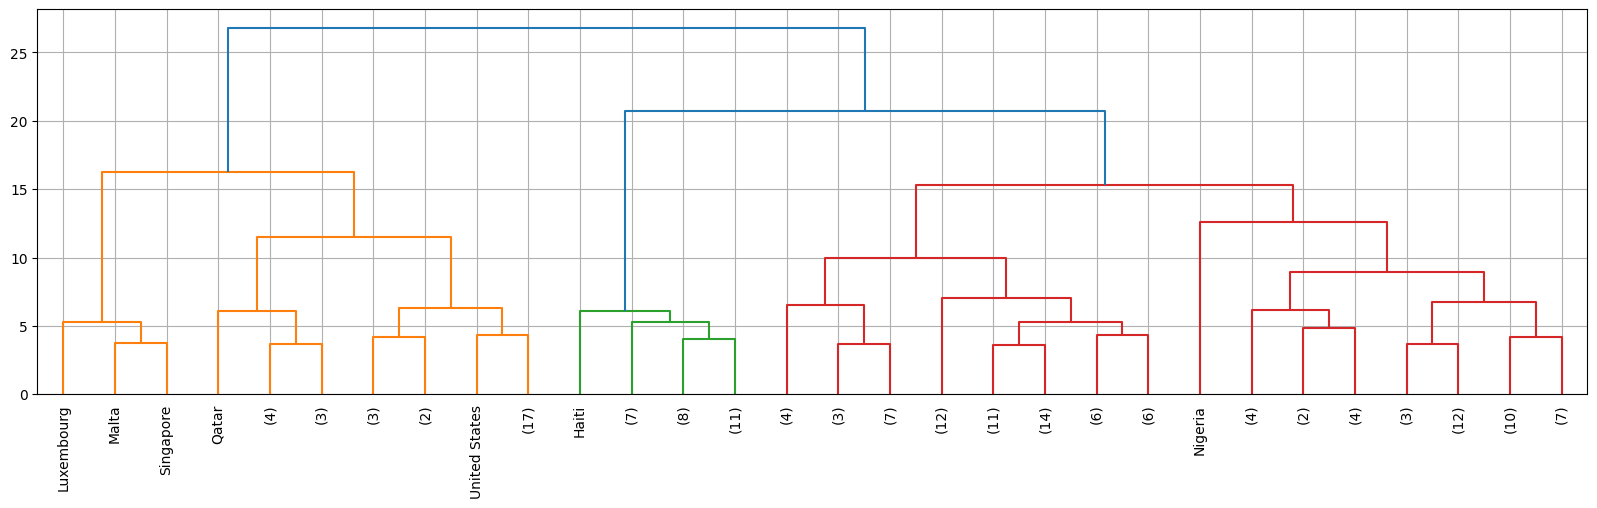

In [218]:
plt.figure(figsize=(20, 5))
Z = linkage(df_scaled, method='ward')
den = dendrogram(Z, labels=df['country'].values, truncate_mode='lastp', leaf_rotation=90)
plt.grid(True)
plt.show()


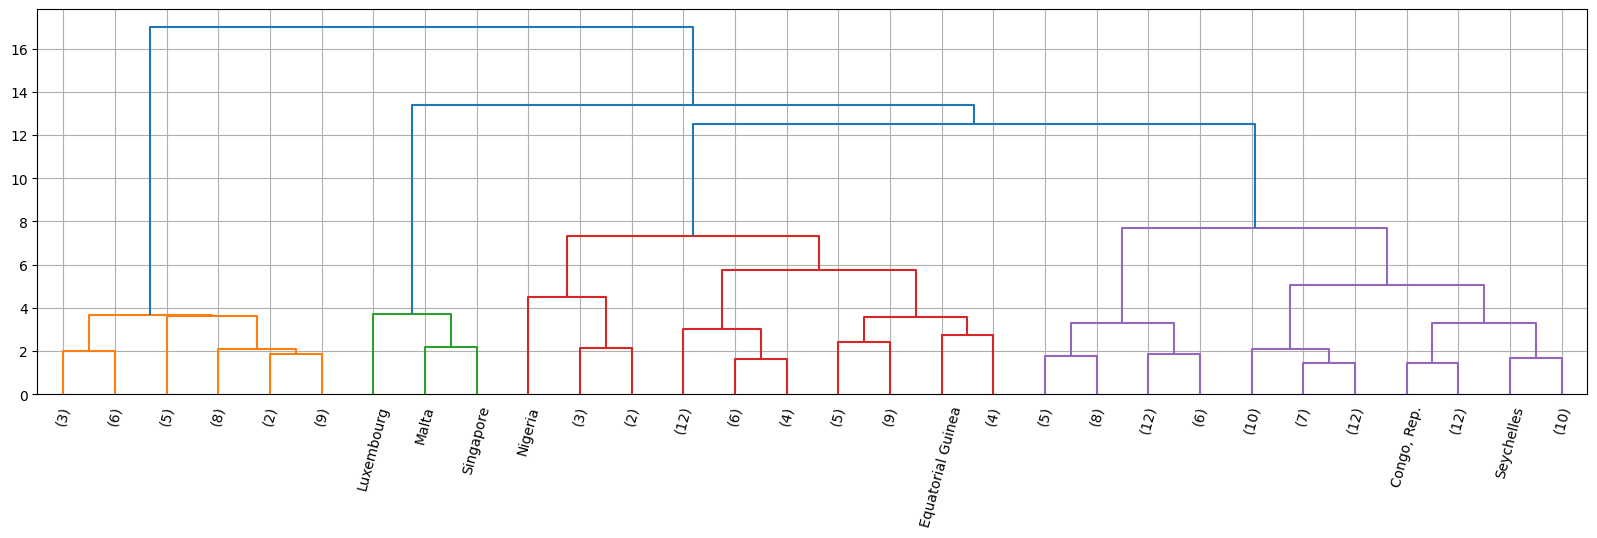

In [219]:
plt.figure(figsize=(20, 5))
Z = linkage(df_scaled_average, method='ward')
den = dendrogram(Z, labels=df_average['country'].values, truncate_mode='lastp', leaf_rotation=75)
plt.grid(True)
plt.show()

### *Based on the dendrogram, choose a reasonable number of clusters `(5 pts)`*
*i choosed number 4 because based from the main cluster it produces 4 grouped patterns, and we are choosing distances between individual data points and by choosing the top cluster or "sub cluster" we are throwign away the throwing away data and destroying the entire structure of how distances should be calculated*



### **Put your answer here**



Perform Agglomerative Clustering using your chosen cluster count `(10 pts)`
- Attach the cluster labels back to the original dataframe.

In [232]:
# put your answer here
model = AgglomerativeClustering(n_clusters=4)
model = model.fit(df_scaled_average)
df_average['cluster'] = model.labels_
df_average.head(10)

,country,health,trade,finance,cluster
0,Afghanistan,1.627045,-0.726043,-0.641753,3
1,Albania,-0.700329,-0.256572,-0.594307,0
2,Algeria,-0.443281,-0.359982,0.064304,1
3,Angola,1.793515,0.390996,0.192453,3
4,Antigua and Barbuda,-0.751906,0.329722,-0.295473,0
5,Argentina,-0.402725,-1.089284,0.610878,1
6,Armenia,-0.922032,-0.479622,-0.529760,0
7,Australia,-0.564285,-0.974460,1.387114,1
8,Austria,-0.468026,0.242840,1.263624,1
9,Azerbaijan,-0.350361,-0.215912,0.061077,1


## 7. Visualizing Cluster Results

Create a scatter plot using any 2 meaningful features, colored by cluster `(10 pts)`
- Choose variables that make socioeconomic sense (e.g., GDP per capita vs. life expectancy).

In [233]:
df_average.groupby('cluster')[['health','trade','finance']].mean()


,health,trade,finance
cluster,,,
0,-0.351405,0.029803,-0.454433
1,-0.511552,-0.107265,1.142286
2,-0.924706,5.107853,2.135790
3,1.707124,-0.387441,-0.664316


In [240]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_average[["country", "cluster"]])


                            country  cluster
0                       Afghanistan        3
1                           Albania        0
2                           Algeria        1
3                            Angola        3
4               Antigua and Barbuda        0
5                         Argentina        1
6                           Armenia        0
7                         Australia        1
8                           Austria        1
9                        Azerbaijan        1
10                          Bahamas        1
11                          Bahrain        1
12                       Bangladesh        0
13                         Barbados        0
14                          Belarus        1
15                          Belgium        1
16                           Belize        0
17                            Benin        3
18                           Bhutan        0
19                          Bolivia        0
20           Bosnia and Herzegovina        0
21        

In [250]:
import plotly.express as px

fig = px.scatter_3d(
    df_average,
    x='health',
    y='trade',
    z='finance',
    color='cluster',
    color_discrete_sequence=px.colors.sequential.Viridis,  # SAME PALETTE
    title='3D Scatter Plot of Clusters (Health, Trade, Finance)'
)

fig.show()


<b>Describe the characteristics of each cluster `(5 pts)`
<br> What patterns can you infer about country groupings?</b>


<em>
<b>Cluster 0 – Developing and middle-income countries</b>

This group has slightly below-average health and finance scores, with trade levels close to the global average. These are mostly developing countries with moderate economic activity and stable but not high financial strength. They form the “middle tier” of global development.

<b>Cluster 1 – Economically developed countries</b>

Countries in this cluster have the highest finance values among the large clusters. Their financial indicators are strongly above average, reflecting high income and stronger economic performance. Health and trade are slightly below average after scaling, but overall this group represents advanced economies such as the US, UK, Japan, Germany, and other high-income nations.

<b>Cluster 2 – Very high-trade and wealthy small economies</b>

This cluster is small but extreme: it contains countries with exceptionally high trade and finance values (for example, Singapore, Luxembourg, and Malta). Their trade values are far above global averages because these countries rely heavily on exports/imports relative to the size of their economies. They are statistical outliers and represent the wealthiest and most globally connected economies.

<b>Cluster 3 – Low-income and least-developed countries</b>

Countries in this cluster show low trade and very low finance scores, indicating weak economic activity and low income levels. Many countries here are in Sub-Saharan Africa or are facing conflict or poverty. This cluster reflects the lowest-performing economies.
</em>


## 8. Reflection
<b>Write a short reflection on what socioeconomic insights hierarchical clustering revealed about global development patterns. `(10 pts)`</b>

<em>
Hierarchical clustering provided a clear view of how countries differ in terms of development by grouping them based on health, trade, and financial indicators. The clusters revealed that global development is not random countries tend to form natural groups that reflect shared socioeconomic conditions. For example, one cluster contained the least-developed nations, characterized by low financial capacity, limited trade activity, and weaker health outcomes. Another large cluster represented developing countries that are improving but still have moderate economic performance.

Meanwhile, high-income countries formed their own cluster, united by strong financial indicators and more stable socioeconomic systems. A small but distinct cluster stood out as well countries with extremely high trade and financial activity, showing how a few nations operate as global economic hubs. Overall, hierarchical clustering highlighted that global development exists on a spectrum, with clear divides between low-income, middle-income, and high-income countries. It showed how economic strength, health conditions, and trade integration interact to shape a country’s development profile and how these similarities naturally form meaningful global patterns.
</em>